## 📘 **Applications of Explainable AI in Predictive Modelling**  
---

🏫 Week 13  
📅 Date: 2025-05-21  
🧑‍🏫 Author: Irena Zimovska

---



In [1]:
import matplotlib.pyplot as plt
import numpy as np  
import os

import torch
import torchvision
from torchvision import models
import lime
import json
import torch
from PIL import Image



# check the version of PyTorch
print(torch.__version__)

2.7.0


# **Explainable AI methods for image data**

Sometimes the model making a decision takes into account the features corresponding not to the real objects, but rather to accidental artifacts present at the images. 

A good example is covered in paper ["Why Should I Trust You?" 🎓[arxiv]](https://arxiv.org/abs/1602.04938), where the authors classified husky and wolves images of which were selected so that there was snow on the images with husky and for wolves - there was not.

<center><img src="https://edunet.kea.su/repo/EduNet-web_dependencies/dev-2.4/L14/2_bad_models_prediction.png" alt="alttext" width="400"/></center>

<center><em>Source: <a href="https://arxiv.org/pdf/1602.04938.pdf">Explaining the Predictions of Any Classifier</a></em></center>

---

## **LIME (Local Interpretable Model-agnostic Explanations)**


The key idea of [__LIME__](https://arxiv.org/abs/1602.04938) is to construct a **local approximation of a hard-to-interpret** (black-box) model using an **easy-to-interpret** (glass-box) model.

Let us break this idea down step by step:

1. **Local approximation** means that we take **a single instance** and **perturb** it (modify its features) in order to create a small dataset localized around the original instance.
2. A **hard-to-interpret model** is the model we want to explain (our **black box**). We use it to obtain **predictions** for the dataset generated from that single instance.
3. As a result, we obtain a **dataset** containing **features** and **predictions** from the black box. We then train a **glass box** on this dataset — an **interpretable model** for which we can estimate feature importance, such as a linear model or a decision tree.

The idea behind **LIME** can be illustrated as follows:

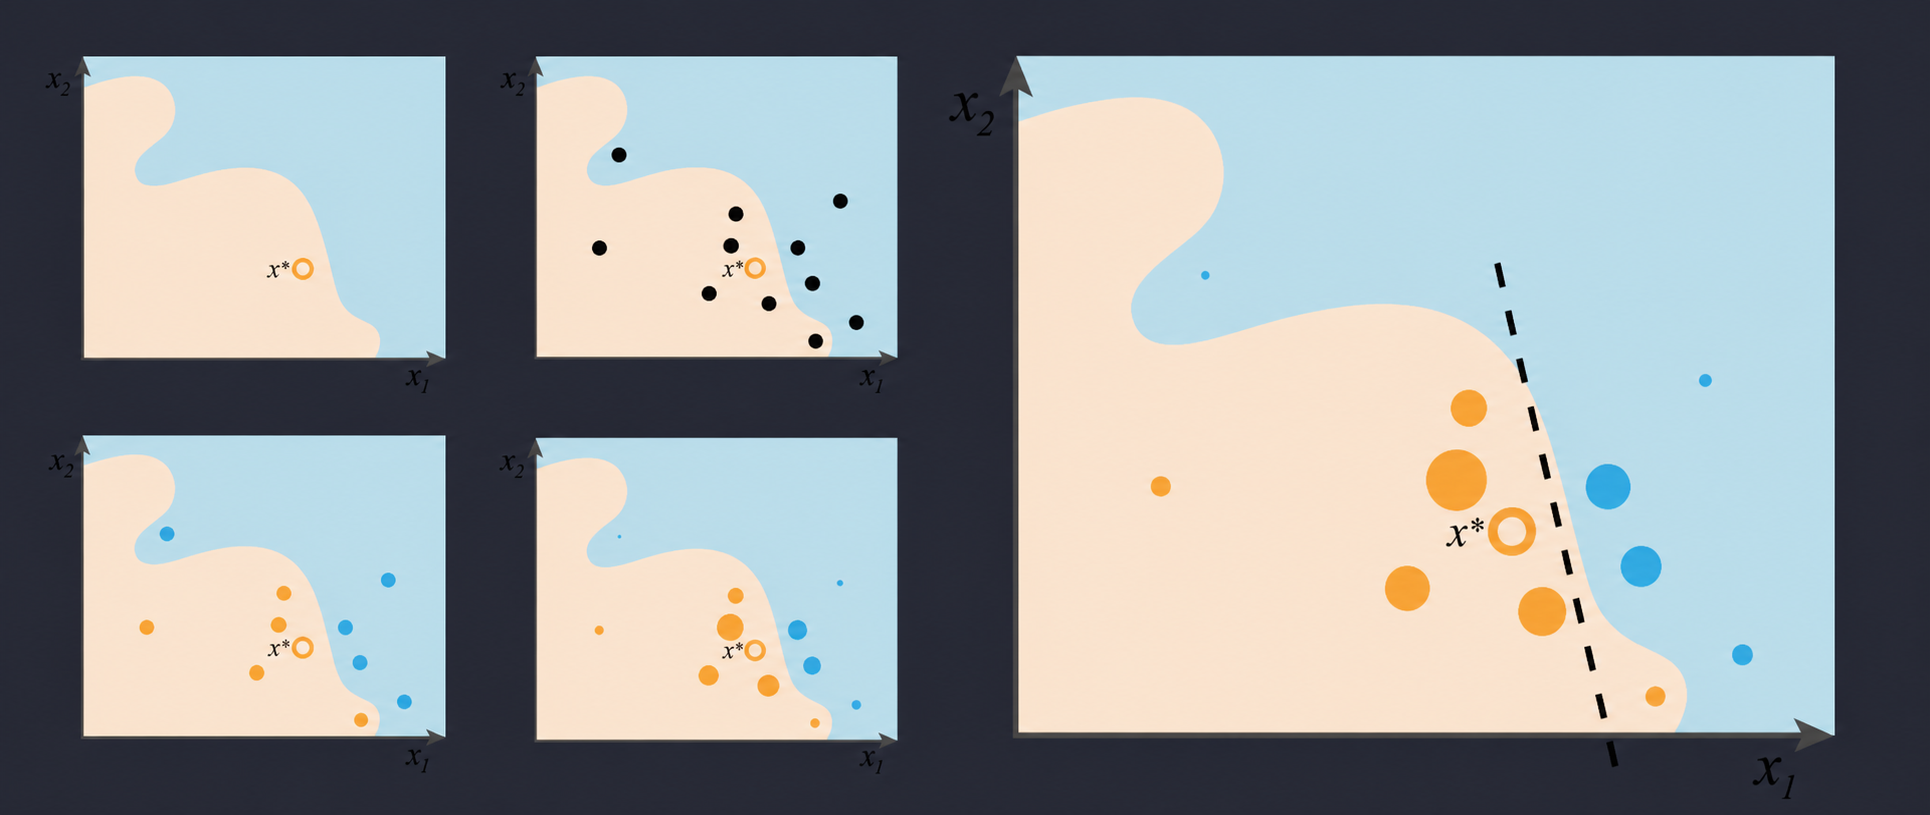

Along the **axes**, we plot the values of **two continuous features**. Initially, we have a hard-to-interpret model that partitions the feature space into two regions separated by a complex decision boundary.

**Step 1.** Select a single instance for which we want to obtain a local explanation (in the illustration, this is $\large x^*$).

**Step 2.** Sample new instances around the instance of interest (the black points).

**Step 3.** Use the original model to label the sampled points, obtaining a new dataset that represents the local region around the instance of interest.

**Step 4.** Assign weights to the instances in the local dataset based on their distance to the instance of interest.

**Step 5.** Train a weighted linear model on the resulting local dataset. In the local neighborhood of the instance of interest, this linear model behaves similarly to the original complex model. We then use the feature importance of the simple linear model as an estimate of feature importance for the complex model in that local region.

### Algorithm description

Our goal is to find a **glass-box** model \(g(x)\) that locally approximates the **black-box** model \(f(x)\) in the neighborhood of the instance of interest $x^*$. Let $G$ be a family of interpretable models (for example, linear models). The desired approximation is defined as follows:

$$\large\hat{g}=\underset{g\in G}{\mathrm{argmin}}\ L\left(f,g,\pi_x\right)+\Omega (g),$$

where $\pi_x$ is a measure, defined via some distance metric, of the **distance between generated instances and the instance of interest**,

$L(f,g,\pi_x)$ is a **loss function** that measures the discrepancy between the predictions of $f(x)$ and $g(x)$,

$\Omega (g)$ is a **complexity penalty** for the model $g(x)$.

In practice, rather than explicitly optimizing this penalty, one often imposes a direct constraint on the complexity of $g(x)$. For decision trees, this may be the **tree depth**; for linear models, it may be the **number of nonzero coefficients**.

In many cases, we need to interpret models with a **very large number of features**. To simplify the problem, LIME can construct **interpretable feature representations**.

The models $f(x)$ and $g(x)$ may operate in **different feature spaces**: $f(x)$ in a space of dimension $p$ ($\mathbb{R}^p$), corresponding to the number of features in the original data, and $g(x)$ in a space of dimension $q$ ($\mathbb{R}^q$), where $q \ll p$. The space $\mathbb{R}^q$ is called an *interpretable representation* of the features. Let a function $h(x)$ map the original feature space $\mathbb{R}^p$ to the interpretable space $\mathbb{R}^q$.

The loss function that measures the discrepancy between the predictions of $f(x)$ and $g(x)$ can then be written as:

$$L(f,g,\pi_x)=\sum_{z,z'}\pi_x(z)(f(z)-g(z'))^2,$$

where $z$ and $z'$ are artificially generated samples in the neighborhood of $x^*$ in the spaces $\mathbb{R}^p$ and $\mathbb{R}^q$, respectively.

We can now assemble the full algorithm for obtaining explanations of variable contributions. In pseudocode:

1. Given: $x^*$ — the **instance to be explained**, $N$ — the size of the artificial dataset in the neighborhood of the target instance, and `distance` — a **distance metric**.
2. Compute $x' = h(x^*)$, that is, map the target instance to a **lower-dimensional interpretable space**.

```python
z_prime = []
for i in range(N):
    z_prime[i] = sample_around(x_prime)
    y_prime[i] = f(z[i])
    pi_x_prime[i] = distance(x_prime, z_prime[i])

return K_Lasso(z_prime, y_prime, pi_x_prime)
```

The output of the algorithm is a linear model that selects $K$ features based on $y'$, $z'$, and $\pi_x'$ (K-Lasso regression).

To implement K-Lasso regression, the function $\Omega(g)$ is defined as:

$$\Omega(g) = \infty \cdot \mathbf{1} \left[ \| w_g \|_0 > K \right]$$

This notation means that the regularization term $\Omega(g)$ takes the value $\infty$ if the number of nonzero weights in $w_g$ exceeds $K$, and $0$ otherwise. This guarantees that the trained linear model $g$ has at most $K$ nonzero coefficients.

### How do we generate samples near the instance of interest?

* For **text**, we can **remove a word**.
* For **images**, we can **segment the image into regions** (superpixels) and then mask them one by one using the same color (for example, the mean color).
* For **tabular data**:
 * for **binary variables** in a low-dimensional space, it is often sufficient to flip the variable value (**0 to 1** and **1 to 0**),
 * for **continuous variables**, several options have been proposed, such as adding **Gaussian noise** or **discretizing** the variable.

### Limitations

This approach allows us to interpret model behavior **only in a local region** around the instance of interest.

In practice, this is often sufficient. It is also **computationally efficient**, since it does not require enumerating all possible feature combinations.

### LIME for images (ResNet‑18)



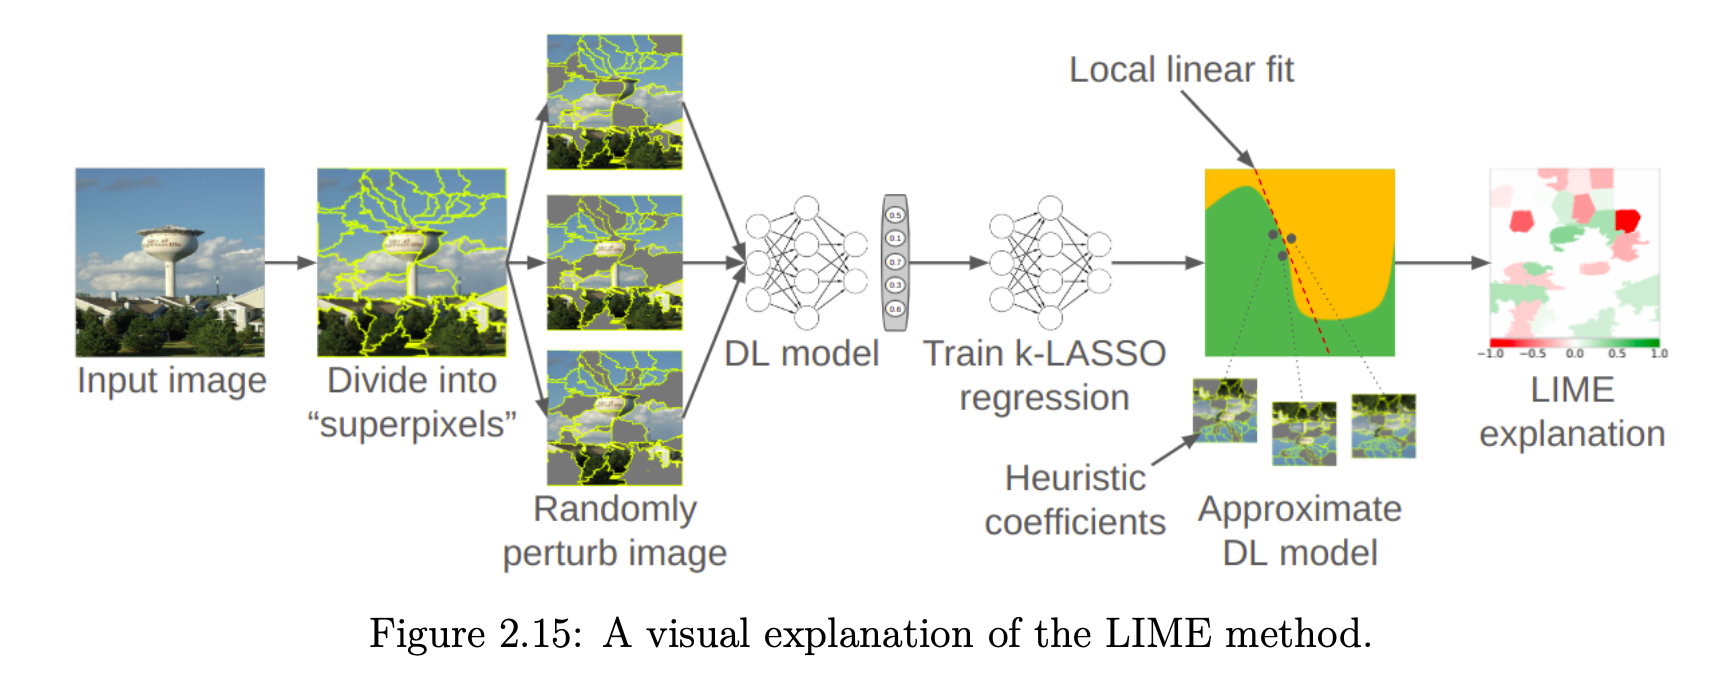


Source: Hryniewska-Guzik, W. (2024). A multi-level perspective on the deep learning models and human-oriented explanations with applications to
medical images (Doctoral dissertation). Warsaw University of Technology, Warsaw, Poland.



Let us see how **interpretable feature representations** work for images.

The figure below shows an example of how **LIME** can be applied to **image classification**.

Imagine that we want to explain the prediction of a classifier that outputs the probability that an image contains a tree frog.

We take the image on the left and segment it into **interpretable components** — contiguous regions (adjacent **superpixels**).

<center><img src="https://edunet.kea.su/repo/EduNet-web_dependencies/dev-2.4/L14/lime_interpretable_components.jpg" alt="alttext" width="550"/></center>

<center><em>Source: <a href="https://www.oreilly.com/content/introduction-to-local-interpretable-model-agnostic-explanations-lime/">Local Interpretable Model-Agnostic Explanations (LIME): An Introduction</a></em></center>

Next, we generate perturbed versions of the image by **turning superpixels on and off**:

* Some regions are kept as in the original image.
* Other regions are replaced by a constant value (for example, filled with the average color).

For each perturbed image, we ask the original classifier for the predicted probability of the target class (“tree frog” in this example). This gives us a dataset of binary superpixel indicators and corresponding predicted probabilities.

<center><img src="https://edunet.kea.su/repo/EduNet-web_dependencies/dev-2.4/L14/lime_explanation_pipeline.jpg" alt="alttext" width="750"/></center>

<center><em>Source: <a href="https://www.oreilly.com/content/introduction-to-local-interpretable-model-agnostic-explanations-lime/">Local Interpretable Model-Agnostic Explanations (LIME): An Introduction</a></em></center>

We then fit a **linear model** in this interpretable space: each feature indicates whether a given superpixel is present or masked. The learned coefficients show which regions (superpixels) are **positively** or **negatively** associated with the class of interest.

By visualizing only the superpixels with the largest positive weights, we obtain a **local explanation**: the parts of the image that most strongly support the classifier’s decision for this particular instance.

<center><img src="https://edunet.kea.su/repo/EduNet-web_dependencies/dev-2.4/L14/lime_explanation_google_inception.jpg" alt="alttext" width="750"/></center>

<center><em>Source: <a href="https://www.oreilly.com/content/introduction-to-local-interpretable-model-agnostic-explanations-lime/">Local Interpretable Model-Agnostic Explanations (LIME): An Introduction</a></em></center>

#### Analysis of ResNet-18 sample

First, we will load and preprocess an image. Then we will use a ResNet‑18 model pretrained on ImageNet to classify this image. After that, we will build explanations for the top‑probability predicted classes using LIME.

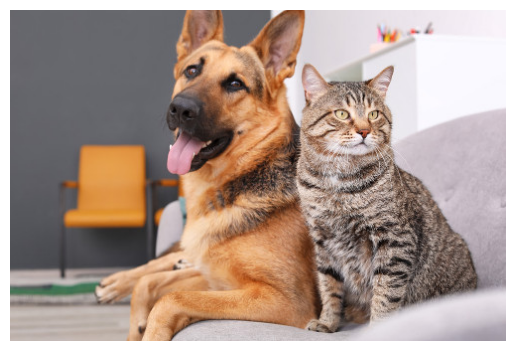

In [2]:
def get_image(path):
    with open(os.path.abspath(path), "rb") as f:
        with Image.open(f) as img:
            return img.convert("RGB")


img = get_image("cat_and_dog1.jpg")
plt.imshow(img)
plt.axis("off")
plt.show()

Now we need to convert this image into a PyTorch tensor and normalize it so that it can be passed to our pretrained model.

In [3]:
from torchvision.transforms import v2

# Resize & normalize
def get_input_transform():
    transform = v2.Compose(
        [
            v2.Resize(224),
            v2.CenterCrop((224, 224)),
            v2.ToImage(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ]
    )
    return transform


# Get cropped image from input tensor
def get_reverse_transform():
    transform = v2.Compose(
        [
            v2.Normalize(mean=(0.0, 0.0, 0.0), std=(1 / 0.229, 1 / 0.224, 1 / 0.225)),
            v2.Normalize(
                mean=(-0.485, -0.456, -0.406),
                std=(1.0, 1.0, 1.0),
            ),
            v2.Lambda(lambda x: torch.permute(x, (0, 2, 3, 1))),
            v2.Lambda(lambda x: x.detach().numpy()),
        ]
    )
    return transform


def get_input_tensors(img):
    transform = get_input_transform()
    # Unsqueeze converts single image to batch of 1
    return transform(img).unsqueeze(0)


def get_crop_img(img_tensor):
    transform = get_reverse_transform()
    return transform(img_tensor)[0]

Next, we will load the pretrained ResNet‑18 model available in PyTorch, along with the ImageNet class index.


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights="ResNet18_Weights.DEFAULT")

idx2label, cls2label, cls2idx = [], {}, {}
with open(os.path.abspath("imagenet_class_index.json"), "r") as read_file:
    class_idx = json.load(read_file)
    idx2label = [class_idx[str(k)][1] for k in range(len(class_idx))]
    label2idx = {class_idx[str(k)][1]: k for k in range(len(class_idx))}

In [5]:
# class_idx

Next, we obtain the model’s prediction. Then we pass the raw outputs (logits) through the softmax function to get probabilities and class labels for the top‑5 predictions.

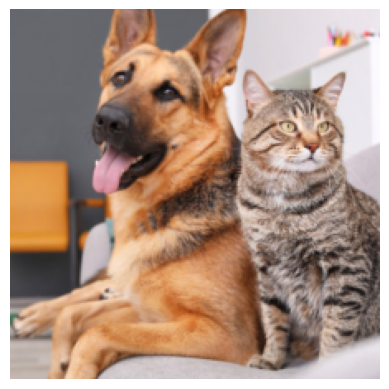

((0.4030768871307373, 235, 'German_shepherd'),
 (0.09531807154417038, 281, 'tabby'),
 (0.06907901167869568, 282, 'tiger_cat'),
 (0.026926252990961075, 285, 'Egyptian_cat'),
 (0.02285182848572731, 811, 'space_heater'))

In [6]:
import torch.nn.functional as F

img_t = get_input_tensors(img)
model = model.to(device)
model.eval()
logits = model(img_t.to(device))

probs = F.softmax(logits, dim=1)
probs5 = probs.topk(5)
plt.imshow(get_crop_img(img_t))
plt.axis("off")
plt.show()
tuple(
    (float(p), int(c), idx2label[int(c)])
    for p, c in zip(
        probs5[0][0].detach().cpu().numpy(), probs5[1][0].detach().cpu().numpy()
    )
)

(tabby — it's also a cat)

Now we will apply LIME.

LIME generates an array of images by creating perturbed versions of the original input image.

To use it, we need to provide the constructor with:
1. The original image as a NumPy array.
2. A classification function that takes an array of perturbed images as input and returns, for each image, the predicted class probabilities as output.

Therefore, we need an auxiliary helper function that processes a batch of images and exposes the model through the LIME API.

In [7]:
def batch_predict(images):  # images are numpy arrays
    model.eval()
    transform = get_input_transform()
    batch = torch.stack(tuple(transform(Image.fromarray(i)) for i in images), dim=0)

    model.to(device)
    batch = batch.to(device)

    logits = model(batch)
    probs = F.softmax(logits, dim=1)
    return probs.detach().cpu().numpy()

We now create an `ImageExplainer` instance and generate an `explanation` object. Note that `LimeImageExplainer` has an important limitation: it only works with `numpy.array` inputs and with 3‑channel images.

In [8]:
import lime
from lime import lime_image

img_t = get_input_tensors(img)

explainer = lime_image.LimeImageExplainer(random_state=42)
explanation = explainer.explain_instance(
    np.array(255 * get_crop_img(img_t)).astype(
        np.uint8
    ),  # LIME assume that input is a numpy array :(
    batch_predict,  # classification function
    top_labels=5,
    hide_color=0,
    num_samples=1000,  # number of images that will be sent to classification function
    random_seed=42,
)

/Users/irenaz/anaconda3/envs/xai-cv-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 1000/1000 [00:13<00:00, 74.86it/s]


Let us display the top‑5 predictions produced via LIME.

P.S. They do not have to match the predictions obtained for the original (unperturbed) image.

In [9]:
for i, id in enumerate(explanation.top_labels):
    print(i, idx2label[id])

0 German_shepherd
1 tabby
2 tiger_cat
3 Egyptian_cat
4 space_heater


We will apply the explanation mask to the image and examine the regions that contribute most to the predicted class.

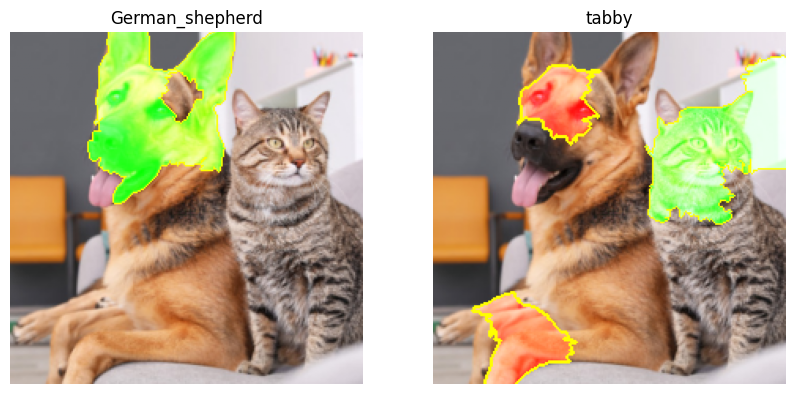

In [10]:
from skimage.segmentation import mark_boundaries

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 10))

for i, id in enumerate(explanation.top_labels[:2]):
    temp, mask = explanation.get_image_and_mask(
        id, positive_only=False, num_features=5, hide_rest=False
    )
    img_boundry = mark_boundaries(temp, mask)
    ax[i].imshow(img_boundry)
    ax[i].set_title(idx2label[id])
    ax[i].axis("off")
    # number of clusters to be shown in the image: num_features=5
    # show or not negatively impacting clusters: positive_only=False
    # first 5 may be only positive

The green region marks the area that most strongly supports the prediction, while the orange regions correspond to areas that least support it. With `positive_only=False`, only the boundaries of these regions are shown.

[[blog] ✏️ Local Interpretable Model-Agnostic Explanations (LIME): An Introduction](https://www.oreilly.com/content/introduction-to-local-interpretable-model-agnostic-explanations-lime/)

[[git] 🐾 Using Lime with PyTorch (tutorial)](https://github.com/marcotcr/lime/blob/master/doc/notebooks/Tutorial%20-%20images%20-%20Pytorch.ipynb)

## **Saliency maps** (**Vanilla Gradients**)

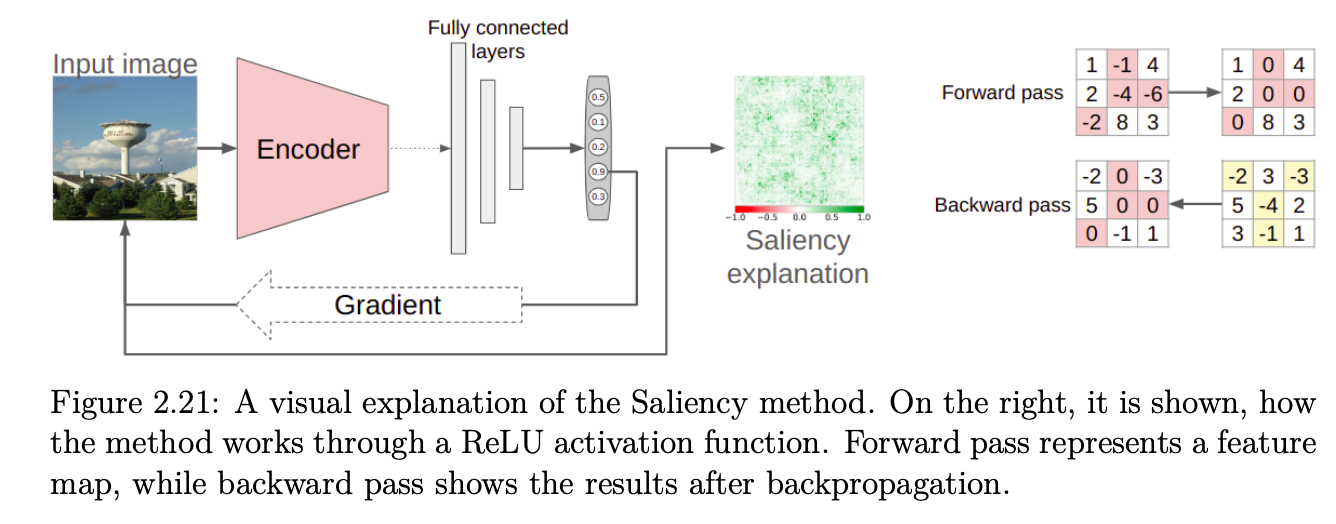

Source: Hryniewska-Guzik, W. (2024). A multi-level perspective on the deep learning models and human-oriented explanations with applications to
medical images (Doctoral dissertation). Warsaw University of Technology, Warsaw, Poland.


Having information about the model's architecture, we can use the **gradient** to understand
how the inputs relate to the output.

In [11]:
print(type(img))
img_t = get_input_tensors(img)

model.to(device)
model.eval()
logits = model(img_t.to(device))

<class 'PIL.Image.Image'>


In [12]:
import torch.nn.functional as F

def top_k_class(logits, k=6):
    prediction = F.softmax(logits, dim=1)
    top_props, top_inds = prediction.topk(k)

    for i in range(k):
        category_name = idx2label[top_inds[0][i].item()]
        score = top_props[0][i].item()
        print(f"{category_name} {top_inds[0][i].item()}: {100 * score:.1f}%")


top_k_class(logits)

German_shepherd 235: 40.3%
tabby 281: 9.5%
tiger_cat 282: 6.9%
Egyptian_cat 285: 2.7%
space_heater 811: 2.3%
malinois 225: 1.2%


We enable gradient computation for the image, make a prediction, and select the most probable logit.

In [13]:
img_t.requires_grad = True  # Tell pytorch to compute grads w.r.t. inputs too

logits = model(img_t.to(device))  # [1,1000] batch of one element, 1000 class scores
top_score, top_idx = logits[0].topk(1)  # Get id of class with best score
id = top_idx[0].item()

print(id, idx2label[id])  # Print the label this class

score = logits[:, id]  # Model output for particular class

235 German_shepherd


For the model output corresponding to our class, we compute the gradient.

In [14]:
# Compute gradients
score.backward(retain_graph=True)

# retain_grad = True is not nessesary
# But if we run this code second time, we got a torch error without it
# because pytorch want to accumulate gradients explicitly

print(img_t.grad.shape)

torch.Size([1, 3, 224, 224])


The input tensor (image) now has a gradient that indicates how each element influenced the
model's output. Let us visualise this gradient.

In [15]:
from matplotlib import pylab as P

# Helper method to display grad
def grad_to_image(raw_grads, percentile=99):
    gradients = raw_grads.detach().cpu().numpy()
    gradients = np.transpose(gradients, (0, 2, 3, 1))[0]

    image_2d = np.sum(np.abs(gradients), axis=2)

    vmax = np.percentile(image_2d, percentile)
    vmin = np.min(image_2d)

    return np.clip((image_2d - vmin) / (vmax - vmin), 0, 1)


def plot_saliency_map(img_tensor, saliency_map):
    plt.rcParams["figure.figsize"] = (10, 5)
    plt.subplot(1, 2, 1)
    img = get_crop_img(img_t)
    plt.imshow(img)
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.imshow(saliency_map, cmap=P.cm.gray, vmin=0, vmax=1)
    plt.axis("off")
    plt.show()

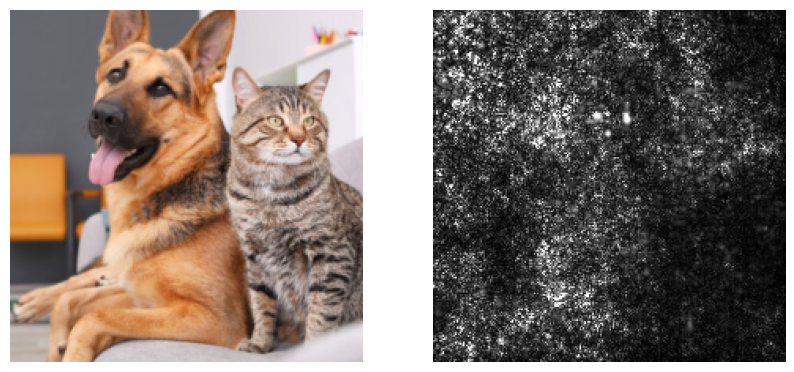

In [16]:
saliency_map = grad_to_image(img_t.grad)
plot_saliency_map(img_t, saliency_map)

Or we could do it using the `captum` library: 

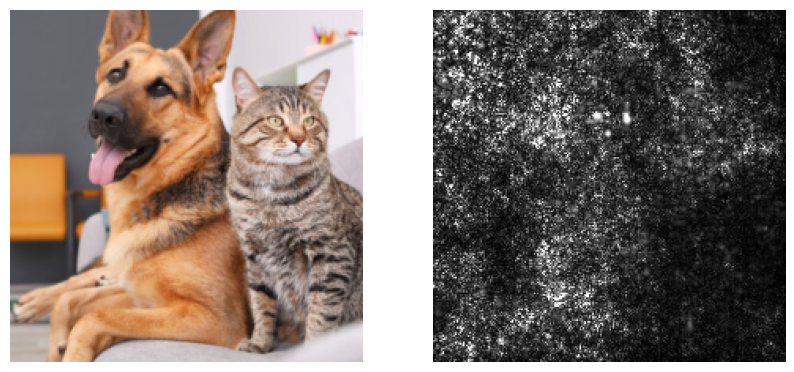

In [17]:
from captum.attr import Saliency

# enable gradients for the input image
img_t = get_input_tensors(img)
img_t.requires_grad_()

# predict and choose the top class
logits = model(img_t)
target_class = logits.argmax(dim=1).item()

# compute saliency map with Captum
saliency = Saliency(model)
grads = saliency.attribute(img_t, target=target_class, abs=True)

# convert to the same 2D map format as before
saliency_map = grad_to_image(grads)
plot_saliency_map(img_t, saliency_map)

The **saliency map** obtained in this way tends to be very noisy.

### The saturation problem

One of the drawbacks of the saliency map produced by the **Vanilla Gradient** method is the
**saturation problem**. In simple terms, the issue can be stated as follows: if a feature
"perfectly" characterises an object's membership in a given class, the gradient with respect
to that feature will be zero. In other words, **Vanilla Gradient** tends to underestimate the
importance of very strong, highly discriminative features.

<center><img src ="https://edunet.kea.su/repo/EduNet-content/dev-2.4/L14/out/saturation_problem_2.png" width="750"></center>

Let us illustrate this with an example. Let $y$ be the output of a neuron with a ReLU
activation function, unit weights, and a bias of $-2$:

$$y = \max(0,\ x_1 + x_2 - 2).$$

If we take feature values $\{x_1 = 1;\ x_2 = 1\}$, the output is $y = 0$.

Now we zero out each feature in turn, introducing perturbations one at a time:
$\{x_1 = 0;\ x_2 = 1\}$ and $\{x_1 = 1;\ x_2 = 0\}$. In both cases the output remains
$y = 0$.

This may create the misleading impression that neither feature has any effect on the result.
Thus, a perturbation-based approach will underestimate the importance of features whose
contribution to the output has reached saturation. Gradient-based methods suffer from the
same issue: the gradient is zero at saturation, so they too will underestimate the importance
of strongly activated features.

The saturation problem is not uncommon. For example, it arises in biology when building
[models 🎓[article]](https://www.nature.com/articles/nmeth.3547) that explain the contribution
of individual mutations to a given property of an organism — a consequence of the degeneracy
of the genetic code.


## **SmoothGrad**


The Vanilla Gradient Ascent saliency map tends to be highly noisy. Several approaches have
been proposed to reduce this noise; one of them is described in
[SmoothGrad: removing noise by adding noise 🎓[arxiv]](https://arxiv.org/pdf/1706.03825.pdf).

As the title suggests, the core idea of **SmoothGrad** is to **add Gaussian noise** to the
original image $x$:

$$x + \mathcal{N}(0, \sigma^2)$$

For a set of noisy images, we compute **saliency maps** using **Vanilla Gradient**:

$$M_c\bigl(x + \mathcal{N}(0, \sigma^2)\bigr)$$

The **saliency maps** obtained from these noisy images are then **averaged**:

$$\text{SmoothGrad} = \frac{1}{n}\sum_{i=1}^{n}
  M_c\bigl(x + \mathcal{N}(0, \sigma^2)\bigr)$$

<center><img src ="https://edunet.kea.su/repo/EduNet-web_dependencies/dev-2.4/L14/smooth_grad.png" width="800">

<em>Source: <a href="https://arxiv.org/pdf/1706.03825.pdf">SmoothGrad: removing noise by adding noise
</a></em></center>


The paper recommends using $n = 50$ and a noise level of $10$–$20\%$.  
The noise level is defined as the ratio

$$\frac{\sigma}{x_{\max} - x_{\min}}$$

### Example with ResNet-18

In [18]:
# ! pip install saliency

In [19]:
import saliency.core as saliency

model = models.resnet18(weights="ResNet18_Weights.DEFAULT")


def call_model_function(img, call_model_args=None, expected_keys=None):
    img_t = torch.tensor(np.transpose(img, (0, 3, 1, 2)))
    transform = v2.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    )
    img_t = transform(img_t)
    img_t.requires_grad_(True)

    model.to(device)
    model.eval()
    logits = model(img_t.float().to(device))

    top_score, top_idx = logits[0].topk(1)  # Get id of class with best score
    target_class_idx = top_idx[0].item()

    output = logits[:, target_class_idx]
    grads = torch.autograd.grad(
        output, img_t, grad_outputs=torch.ones_like(output)
    )  # output[:, target_class_idx]
    grads = torch.movedim(grads[0], 1, 3)
    gradients = grads.detach().numpy()
    return {saliency.base.INPUT_OUTPUT_GRADIENTS: gradients}

In [20]:
img = get_image("cat_and_dog1.jpg")
img_t = get_input_tensors(img)
img_arr = get_crop_img(img_t)

gradient_saliency = saliency.GradientSaliency()

vanilla_mask_3d = gradient_saliency.GetMask(img_arr, call_model_function)
smoothgrad_mask_3d = gradient_saliency.GetSmoothedMask(img_arr, call_model_function)

# Call the visualization methods to convert the 3D tensors to 2D grayscale.
vanilla_mask_grayscale = saliency.VisualizeImageGrayscale(vanilla_mask_3d)
smoothgrad_mask_grayscale = saliency.VisualizeImageGrayscale(smoothgrad_mask_3d)

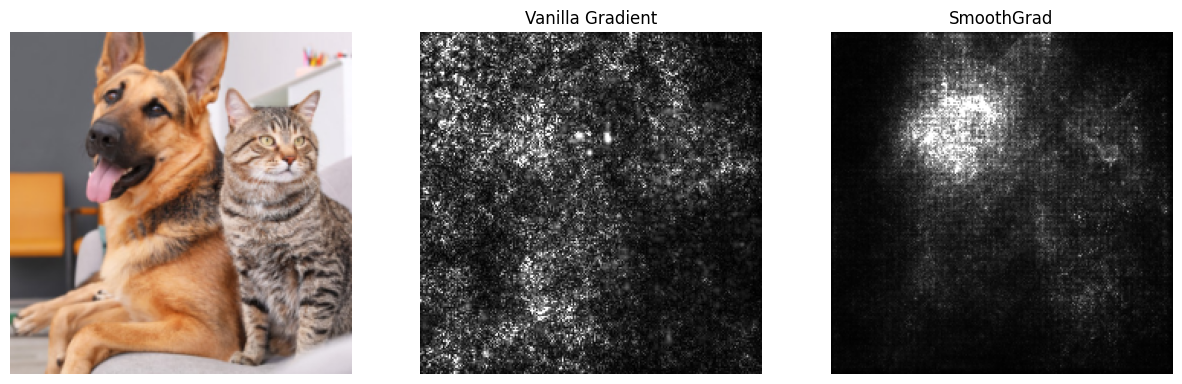

In [21]:
from matplotlib import pylab as P

def ShowGrayscaleImage(im, title="", ax=None):
    if ax is None:
        P.figure()
    P.axis("off")
    P.imshow(im, cmap=P.cm.gray, vmin=0, vmax=1)
    P.title(title)


# Set up matplot lib figures.
plt.rcParams["figure.figsize"] = (15, 5)

plt.subplot(1, 3, 1)
plt.imshow(img_arr)
plt.axis("off")

ShowGrayscaleImage(
    vanilla_mask_grayscale, title="Vanilla Gradient", ax=P.subplot(1, 3, 2)
)
ShowGrayscaleImage(smoothgrad_mask_grayscale, title="SmoothGrad", ax=P.subplot(1, 3, 3))

## **Integrated Gradients**

The next method we will consider is called **Integrated Gradients**. It is similar to **SmoothGrad** in the sense that we deliberately “corrupt” the images. Let us see how it works.

In the **Integrated Gradients** method, we choose a **baseline image** $x'$. Typically, a black image is used as the baseline (all RGB channels set to zero). The input image $x$ that we want to explain is then mixed with the baseline $x'$ using a proportion $\alpha$:

$$\large x' + \alpha (x - x')$$

In this way, we corrupt the image and then gradually restore it.

<center><img src ="https://edunet.kea.su/repo/EduNet-web_dependencies/dev-2.4/L14/ig_fireboat_1.png" width="900">

<em>Source: <a href="https://www.tensorflow.org/tutorials/interpretability/integrated_gradients">Tensorflow tutorials: Integrated gradients
</a></em></center>

For the image mixture, we compute the **Vanilla Gradient**:

$$\large M_c(x' + \alpha(x - x'))$$

The formula underlying **Integrated Gradients** was proposed in [the paper 🎓[arXiv]](https://arxiv.org/pdf/1703.01365.pdf). It represents the integral of the gradient along the path that gradually restores the image.

$$\large \text{IntegratedGrads}(x) = (x - x') \cdot \int_{\alpha=0}^{1} M_c(x' + \alpha(x - x')) \, d\alpha$$

The factor $(x - x')$ appears because the gradient was originally taken with respect to $dx = (x - x') d\alpha$.

In practice, the integral is approximated by a sum:

$$\large \text{IntegratedGrads}(x) \approx (x - x') \cdot \sum_{k=1}^{m} M_c\left(x' + \frac{k}{m}(x - x')\right) \cdot \frac{1}{m}$$

The value of $m$ is typically chosen in the range from $20$ to $300$.

Example:

<center><img src ="https://edunet.kea.su/repo/EduNet-web_dependencies/dev-2.4/L14/ig_fireboat.png" width="500">

<em>Source: <a href="https://www.tensorflow.org/tutorials/interpretability/integrated_gradients">Tensorflow tutorials: Integrated gradients
</a></em></center>

Integrated Gradients partially mitigates the saturation problem by modifying the input image along the path from the baseline to the original image.

In [22]:
output = model(img_t.to(device))
output = F.softmax(output, dim=1)
prediction_score, pred_label_idx = torch.topk(output, 1)

pred_label_idx.squeeze_()
predicted_label = idx2label[pred_label_idx.item()]
print("Predicted:", predicted_label, "(", prediction_score.squeeze().item(), ")")

Predicted: German_shepherd ( 0.4030768871307373 )


In [23]:
from captum.attr import IntegratedGradients

integrated_gradients = IntegratedGradients(model)
attributions_ig = integrated_gradients.attribute(
    img_t.to(device), target=pred_label_idx, n_steps=200
)

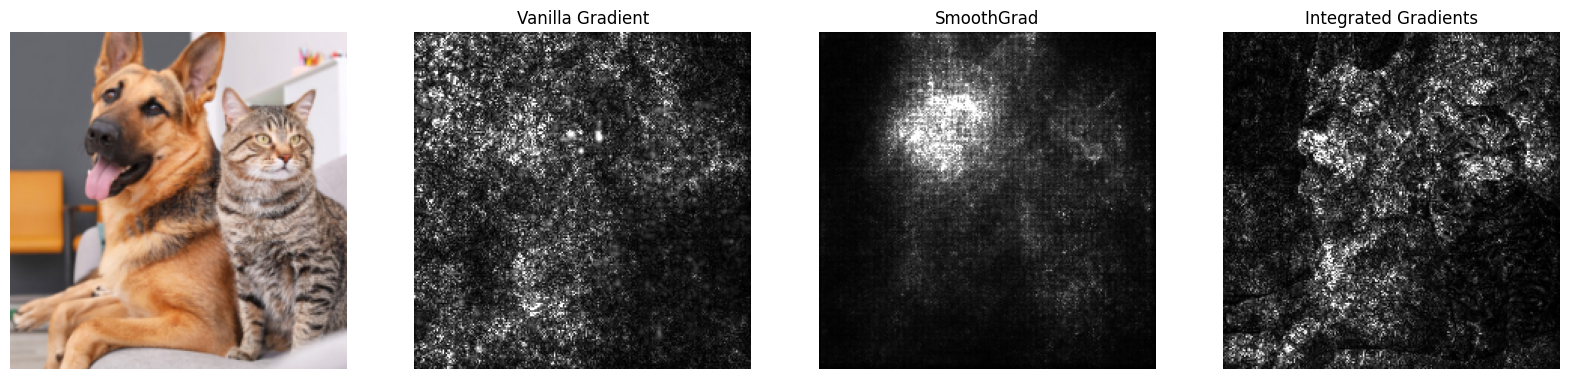

In [24]:
saliency_map = grad_to_image(attributions_ig)

def ShowGrayscaleImage(im, title="", ax=None):
    if ax is None:
        P.figure()
    P.axis("off")
    P.imshow(im, cmap=P.cm.gray, vmin=0, vmax=1)
    P.title(title)

# Set up matplotlib figures
plt.rcParams["figure.figsize"] = (20, 5)

plt.subplot(1, 4, 1)
plt.imshow(img_arr)
plt.axis("off")

ShowGrayscaleImage(
    vanilla_mask_grayscale, title="Vanilla Gradient", ax=P.subplot(1, 4, 2)
)
ShowGrayscaleImage(smoothgrad_mask_grayscale, title="SmoothGrad", ax=P.subplot(1, 4, 3))
ShowGrayscaleImage(saliency_map, title="Integrated Gradients", ax=P.subplot(1, 4, 4))



> "Integrated Gradients (IG) calculates the integral of gradients along a path between a baseline input and the instance to be explained. A baseline
is defined as the absence of a feature in an input. The authors considered black as a base
line. The general idea is to create a series of images that shows an incremental change
from a baseline to an input. For each of these images, a gradient of the model’s pre
diction is computed. Then, gradients are averaged as an integral approximation because a computation of definite integral is not always numerically possible. Finally, the averaged
gradients are scaled by the difference between the input image and the baseline.

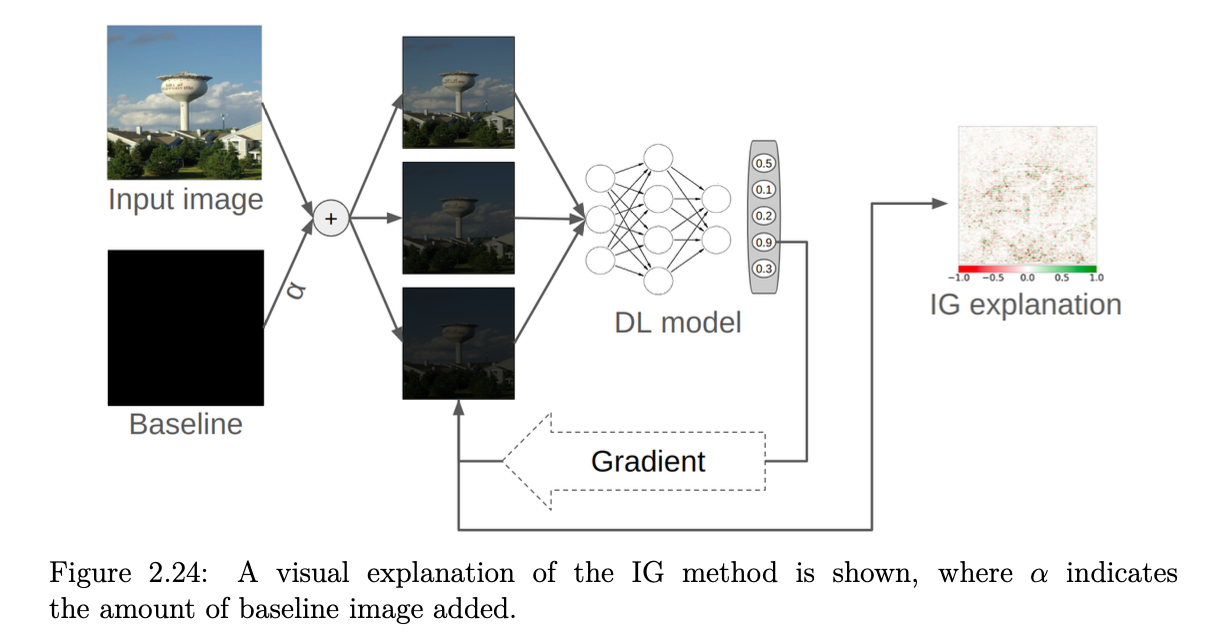

Source: Hryniewska-Guzik, W. (2024). A multi-level perspective on the deep learning models and human-oriented explanations with applications to
medical images (Doctoral dissertation). Warsaw University of Technology, Warsaw, Poland.


## **Grad-CAM**

<center><img src="https://edunet.kea.su/repo/EduNet-web_dependencies/dev-2.4/L14/gradcam-architecture.png" alt="alttext" width="800"/></center>

<center><em>Source: <a href="https://learnopencv.com/intro-to-gradcam">GradCAM – Enhancing Neural Network Interpretability in the Realm of Explainable AI</a></em></center>

After each **convolutional layer** in a neural network, we obtain **feature maps** that preserve information about the **spatial locations of objects** in the original image. All feature values within a single channel are produced by applying the same transformation (the same convolution with shared weights) to the input, which means that **one channel** corresponds to the **activation map of a single feature**.

Let us inspect the feature maps for **ResNet‑18**. To do this, we will load the model together with its pretrained weights.

We are interested in high-level features extracted by the last convolutional layers. ResNet‑18 was trained on ImageNet with an input image size of $224\times224$. Let us examine the tensor shape at the output of the last convolutional layer.

In [91]:
# ! pip install torchsummary

In [25]:
from torchsummary import summary

model = models.resnet18(weights="ResNet18_Weights.DEFAULT")

summary(model.to("cpu"), (3, 224, 224), device="cpu")

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

At the last convolutional layer, we obtain $512$ feature maps of size $7\times7$. To store them, we will register a forward hook that saves the activation values at the output of this layer.

In [26]:
from collections import defaultdict


def get_forward_hook(history_dict, key):
    def forward_hook(self, input_, output):
        history_dict[key] = output.detach().clone()

    return forward_hook


def register_model_hooks(model):
    hooks_data_history = defaultdict(list)
    forward_hook = get_forward_hook(hooks_data_history, "feature_map")
    model._modules["layer4"].register_forward_hook(forward_hook)
    return hooks_data_history

We first preprocess the image: we resize it to $224 \times 224$ pixels and normalize it using the standard ImageNet statistics (channel-wise mean and standard deviation).


In [27]:
img_t = get_input_tensors(img)

We now pass the preprocessed image through the network and store the activation values.

In [28]:
model = model.eval()
history = register_model_hooks(model)
output = model(img_t)

print(history["feature_map"].shape)

torch.Size([1, 512, 7, 7])


Next, we plot the first 6 feature maps. To stretch each map to the full image size, we use the `extent` parameter and set `interpolation='bilinear'`.

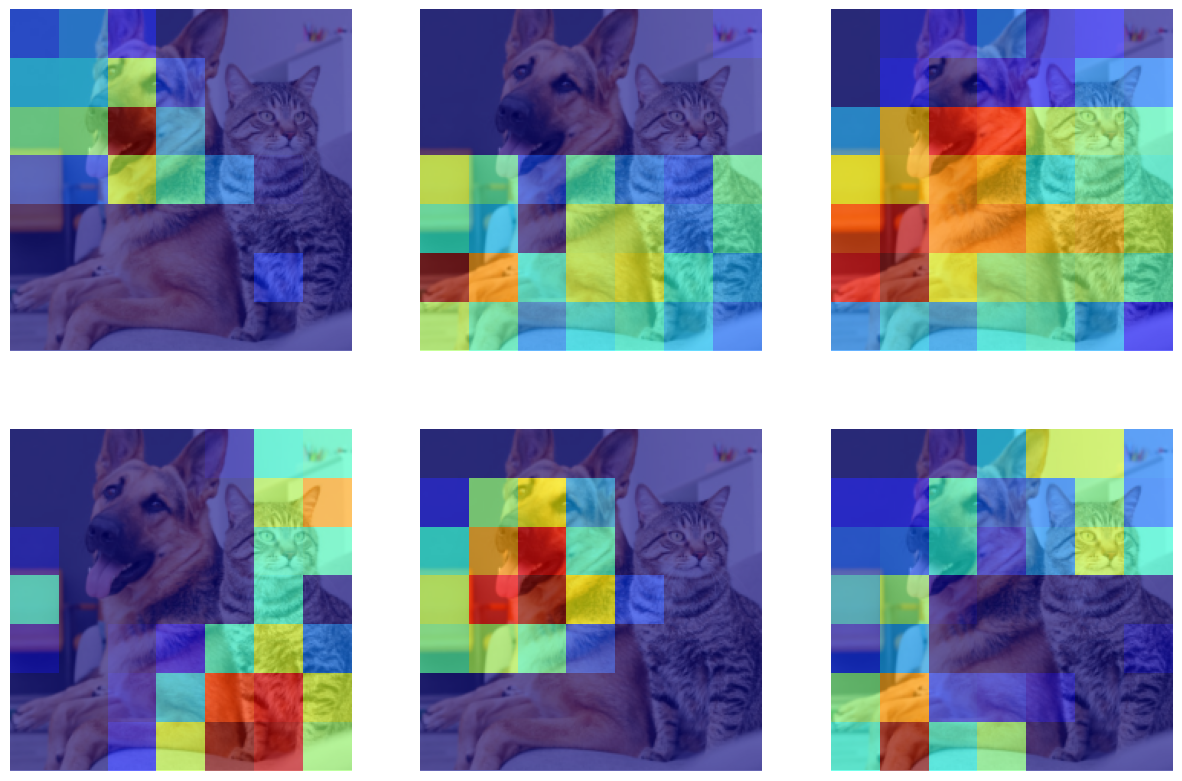

In [29]:
plt.figure(figsize=(15, 10))

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(img_arr)
    plt.imshow(
        history["feature_map"][0][i],
        alpha=0.6,
        extent=(0, 224, 224, 0),
        interpolation="nearest",
        cmap="jet",
    )
    plt.axis("off")

plt.show()

Let us recall the model’s prediction for this image.

In [30]:
import torch.nn.functional as F

number_of_top_classes = 6

prediction = F.softmax(output, dim=1)
top_props, top_inds = prediction.topk(number_of_top_classes)


for i in range(number_of_top_classes):
    category_name = idx2label[top_inds[0][i].item()]
    score = top_props[0][i].item()
    print(f"{category_name} {top_inds[0][i].item()}: {100 * score:.1f}%")

German_shepherd 235: 36.1%
tabby 281: 7.1%
tiger_cat 282: 4.2%
space_heater 811: 3.2%
Egyptian_cat 285: 2.9%
hamper 588: 1.5%


We have seen how different feature maps correspond to specific regions of the image. Now we want to understand how these features relate to the predicted class. Recall that the gradient points in the direction of the greatest increase of a function. If we select the logit corresponding to the predicted class label and compute its gradient, we can identify which features have positive values (i.e., increasing these features will make the model more confident in its prediction).

Now we will write a hook to store the gradient values. Since we are interested in the gradients at the output of the layer just before `AdaptiveAvgPool2d`, we can average them spatially (the gradient value is constant across each feature map channel), and store only these mean values.

In [31]:
def get_backward_hook(history_dict, key):
    def backward_hook(self, grad_input_, grad_output):  # for tensors
        history_dict[key] = (
            grad_output[0].detach().clone().mean(dim=[2, 3], keepdim=True)
        )

    return backward_hook


def register_model_hooks(model):
    hooks_data_history = defaultdict(list)

    forward_hook = get_forward_hook(hooks_data_history, "feature_map")
    model._modules["layer4"].register_forward_hook(forward_hook)

    backward_hook = get_backward_hook(hooks_data_history, "weight")
    model._modules["layer4"].register_full_backward_hook(backward_hook)
    return hooks_data_history

The final **Grad-CAM** (Class activation map) formula is:

$$\large \text{CAM} = \text{ReLU}(\sum_{i=1}^{Nch}w_iA_i),$$

where $A_i$ are the feature map channels and $w_i$ are the weights obtained by propagating the gradient of the logit corresponding to the target class label through the network. The $\text{ReLU}$  is applied because we are interested only in those features that positively contribute to the chosen class. 

Function, calculating CAM:

In [32]:
def get_cam_map(model, img, class_num):
    history = register_model_hooks(model)

    output = model.eval()(img)
    activation = history["feature_map"]

    output[0, class_num].backward()
    weight = history["weight"]

    cam_map = F.relu((weight[0] * activation[0]).sum(0)).detach().cpu()
    return cam_map

Visualising the importances of the features for the top-6 classes:

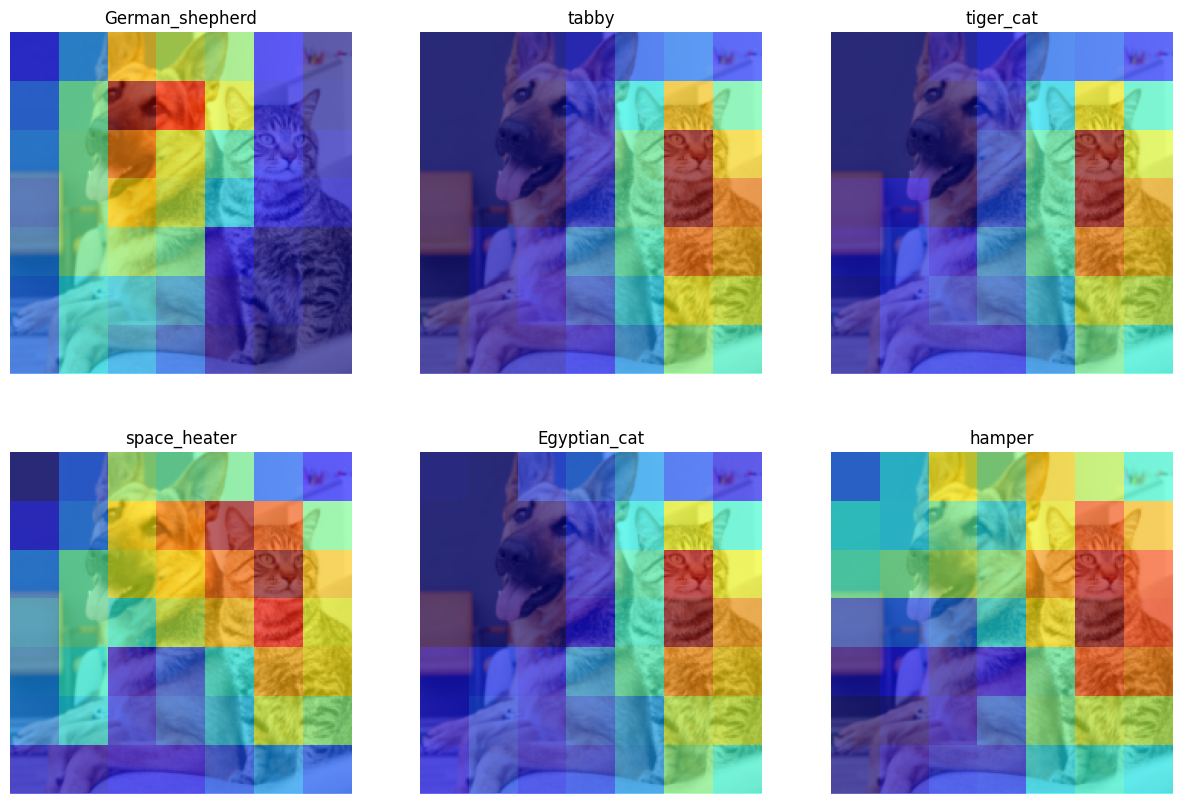

In [33]:
plt.figure(figsize=(15, 10))

for i in range(6):
    cam_map = get_cam_map(model, img_t, top_inds[0][i])

    plt.subplot(2, 3, i + 1)
    plt.imshow(img_arr)
    plt.imshow(
        cam_map,
        alpha=0.6,
        extent=(0, 224, 224, 0),
        interpolation="nearest",
        cmap="jet",
    )
    plt.title(idx2label[top_inds[0][i].item()])
    plt.axis("off")

plt.show()

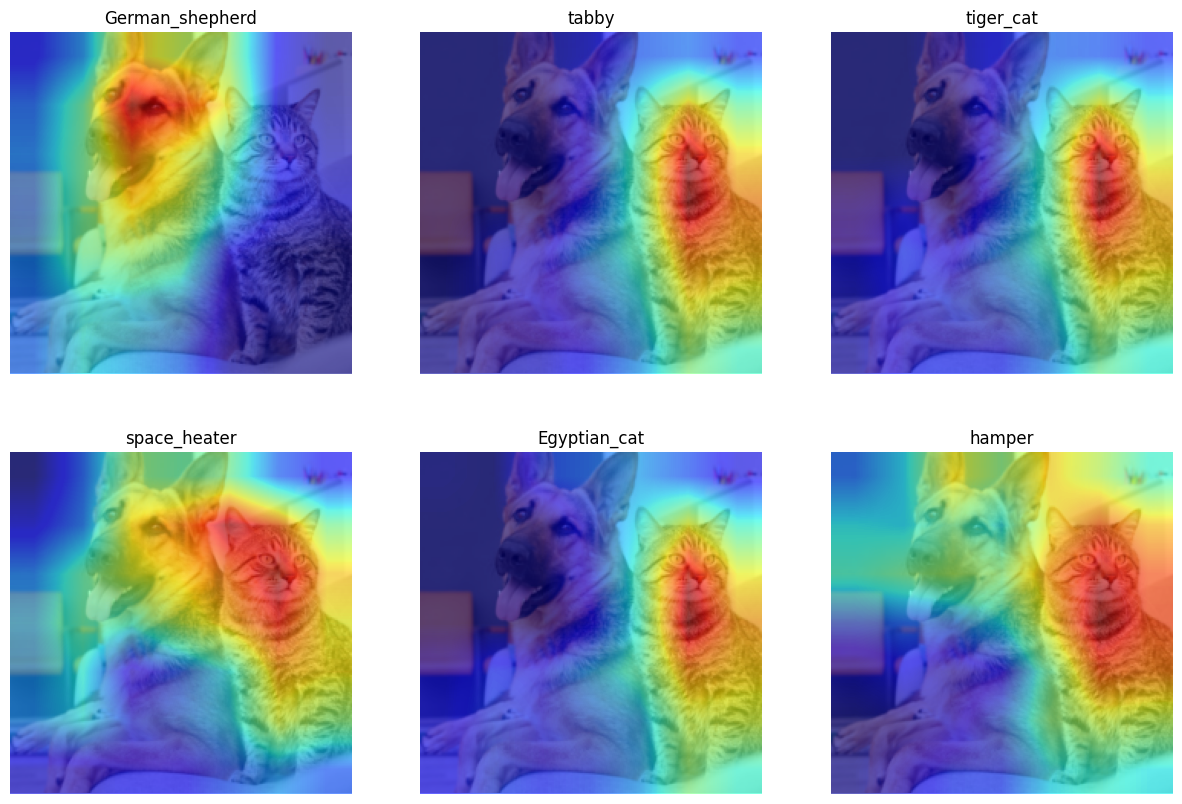

In [34]:
plt.figure(figsize=(15, 10))

for i in range(6):
    cam_map = get_cam_map(model, img_t, top_inds[0][i])

    plt.subplot(2, 3, i + 1)
    plt.imshow(img_arr)
    plt.imshow(
        cam_map,
        alpha=0.6,
        extent=(0, 224, 224, 0),
        interpolation="bilinear",
        cmap="jet",
    )
    plt.title(idx2label[top_inds[0][i].item()])
    plt.axis("off")

plt.show()

Yet for some images Grad-CAM++ would work better then Grad-CAM.

<center><img src="https://edunet.kea.su/repo/EduNet-web_dependencies/dev-2.4/L14/grad_cam_plus_plus.png" alt="alttext" width="600"/></center>

<center><em>Source: <a href="https://arxiv.org/pdf/1710.11063.pdf">Grad-CAM++: Improved Visual Explanations for
Deep Convolutional Networks</a></em></center>

More about implementation of Grad-CAM methods: [Grad-Cam 🛠️[doc]](https://jacobgil.github.io/pytorch-gradcam-book/introduction.html).

### **Guided GradCam (Guided Backprop + GradCAM)**
Computes element-wise product of guided backpropagation attributions with upsampled (non-negative) GradCAM attributions. GradCAM attributions are computed with respect to the layer provided in the constructor, and attributions are upsampled to match the input size. GradCAM is designed for convolutional neural networks, and is usually applied to the last convolutional layer.

Guided Grad-CAM computes the element-wise prod-
uct of Guided Backpropagation attributions with non-negative Grad-CAM attributions.
Thanks to the use of Guided Backpropagation fine-grained heatmaps can be produced.

https://captum.ai/api/guided_grad_cam.html

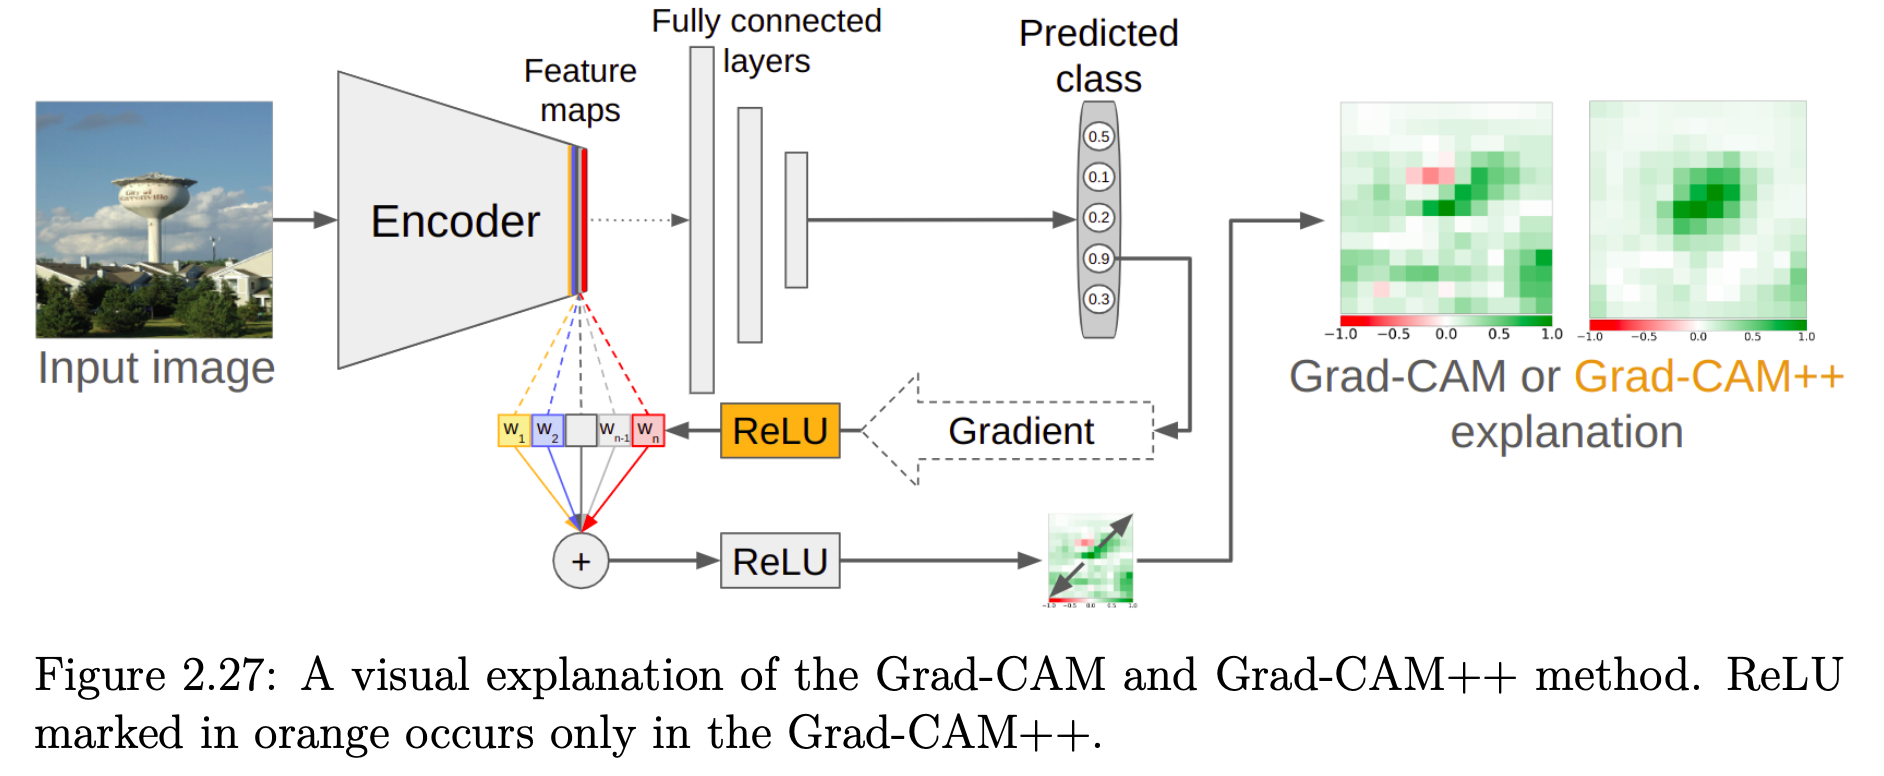

Source: Hryniewska-Guzik, W. (2024). A multi-level perspective on the deep learning models and human-oriented explanations with applications to
medical images (Doctoral dissertation). Warsaw University of Technology, Warsaw, Poland.
